In [1]:
from datascience import *
import numpy as np

%matplotlib inline
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')

# Where should Lawton retire?

In [2]:
income = Table.read_table('data/us-median-income-2023.csv')
income

Geographic Area Name,Median income estimate
Alabama,33108
Alaska,43069
Arizona,39900
Arkansas,32294
California,41901
Colorado,46958
Connecticut,46415
Delaware,41678
District of Columbia,70144
Florida,36270


In [5]:
income = income.take(np.arange(52, income.num_rows))

In [6]:
income

Geographic Area Name,Median income estimate
"Abanda CDP, Alabama",34911
"Abbeville city, Alabama",21678
"Adamsville city, Alabama",31873
"Addison town, Alabama",30833
"Akron town, Alabama",22500
"Alabaster city, Alabama",43502
"Albertville city, Alabama",29150
"Alexander City city, Alabama",27114
"Alexandria CDP, Alabama",41685
"Aliceville city, Alabama",18750


In [7]:
income.where(0, are.containing('Fresno'))

Geographic Area Name,Median income estimate
"Centerville CDP (Fresno County), California",-
"Fresno city, California",33148
"Fresno CDP, Ohio",16488
"Fresno CDP, Texas",42540
"Los Fresnos city, Texas",33168
"Los Fresnos CDP, Texas",45057


In [8]:
income.where(0, are.containing('Clovis'))

Geographic Area Name,Median income estimate
"Clovis city, California",47696
"Clovis city, New Mexico",31392


In [10]:
def fix(x):
    try:
        return int(x)
    except:
        return -1

income = income.with_column('Median income estimate', income.apply(fix, 1))

In [11]:
income.where(0, are.containing('Fresno'))

Geographic Area Name,Median income estimate
"Centerville CDP (Fresno County), California",-1
"Fresno city, California",33148
"Fresno CDP, Ohio",16488
"Fresno CDP, Texas",42540
"Los Fresnos city, Texas",33168
"Los Fresnos CDP, Texas",45057


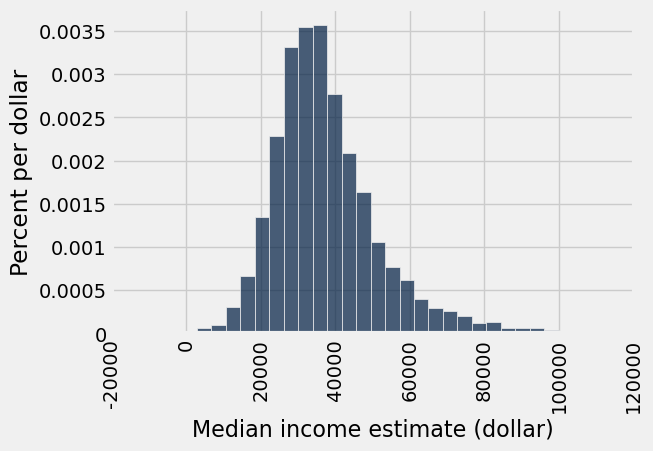

In [15]:
income.where(1, are.between_or_equal_to(0, 100000)).hist(1, bins=25, unit='dollar')

In [16]:
tjs = Table.read_table('data/trader-joes-locations-2025.csv')
tjs

City
"Birmingham, AL"
"Hoover, AL"
"Huntsville, AL"
"Chandler, AZ"
"Gilbert, AZ"
"Glendale, AZ"
"Mesa, AZ"
"Oro Valley, AZ"
"Phoenix, AZ"
"Prescott, AZ"


In [19]:
'Fresno, CA'.split(',')

['Fresno', ' CA']

In [20]:
'Fresno, CA'.split(',')[0]

'Fresno'

In [21]:
'Fresno, CA'.split(',')[1]

' CA'

In [22]:
'Fresno, CA'.split(',')[1].strip()

'CA'

In [28]:
def get_city(s):
    return s.split(',')[0]

def get_state_abbrev(s):
    return s.split(',')[1].strip()

In [27]:
state_abbrevs = Table.read_table('data/state-abbreviations.csv')
state_abbrevs

Name,Abbreviation
Alabama,AL
Alaska,AK
American Samoa,AS
Arizona,AZ
Arkansas,AR
California,CA
Colorado,CO
Connecticut,CT
Delaware,DE
District of Columbia,DC


In [32]:
state_abbrevs.where('Abbreviation', 'CA').row(0).item(0)

'California'

In [33]:
def get_state(s):
    state_abbrev = get_state_abbrev(s)
    return state_abbrevs.where('Abbreviation', state_abbrev).row(0).item(0)

In [34]:
get_city('Fresno, CA')

'Fresno'

In [35]:
get_state_abbrev('Fresno, CA')

'CA'

In [36]:
get_state('Fresno, CA')

'California'

In [37]:
tjs

City
"Birmingham, AL"
"Hoover, AL"
"Huntsville, AL"
"Chandler, AZ"
"Gilbert, AZ"
"Glendale, AZ"
"Mesa, AZ"
"Oro Valley, AZ"
"Phoenix, AZ"
"Prescott, AZ"


In [39]:
tjs = Table().with_columns(
    'City', tjs.apply(get_city, 0),
    'State', tjs.apply(get_state, 0)
)
tjs

City,State
Birmingham,Alabama
Hoover,Alabama
Huntsville,Alabama
Chandler,Arizona
Gilbert,Arizona
Glendale,Arizona
Mesa,Arizona
Oro Valley,Arizona
Phoenix,Arizona
Prescott,Arizona


In [40]:
income

Geographic Area Name,Median income estimate
"Abanda CDP, Alabama",34911
"Abbeville city, Alabama",21678
"Adamsville city, Alabama",31873
"Addison town, Alabama",30833
"Akron town, Alabama",22500
"Alabaster city, Alabama",43502
"Albertville city, Alabama",29150
"Alexander City city, Alabama",27114
"Alexandria CDP, Alabama",41685
"Aliceville city, Alabama",18750


In [41]:
income.where(0, are.containing('Phoenix'))

Geographic Area Name,Median income estimate
"Phoenix city, Arizona",40786
"Phoenix Lake CDP, California",40493
"Phoenix village, Illinois",24000
"Phoenix village, New York",37980
"Phoenix city, Oregon",30893
"Phoenixville borough, Pennsylvania",60073
